In [1]:
# Load the libraries
library(poppr)
library(vcfR)
library(ape)
library(phangorn)
library(ade4)
library(dplyr)


Loading required package: adegenet

Loading required package: ade4


   /// adegenet 2.1.10 is loaded ////////////

   > overview: '?adegenet'
   > tutorials/doc/questions: 'adegenetWeb()' 
   > bug reports/feature requests: adegenetIssues()



Registered S3 method overwritten by 'pegas':
  method      from
  print.amova ade4

This is poppr version 2.9.6. To get started, type package?poppr
OMP parallel support: available


   *****       ***   vcfR   ***       *****
   This is vcfR 1.15.0 
     browseVignettes('vcfR') # Documentation
     citation('vcfR') # Citation
   *****       *****      *****       *****



Attaching package: ‘phangorn’


The following object is masked from ‘package:poppr’:

    upgma


The following object is masked from ‘package:adegenet’:

    AICc



Attaching package: ‘dplyr’


The following object is masked from ‘package:ape’:

    where


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package

In [3]:
genclone_white2011<-readRDS("/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/Structure/Dapc/White_ABfilt_DAPC/white2011_genclone.rds")

In [3]:
ploidy(genclone_white2011)<-1
genclone_white2011


This is a genclone object
-------------------------
Genotype information:

      448 original multilocus genotypes 
      448 haploid individuals
   480058 codominant loci

Population information:

        0 strata. 
        0 populations defined. 

In [2]:
md_white2011<- read.table("/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/VCFs/vcf_gz/Samplemd_files/Total_dataset_TRACwhite2011/White_1052_ctv_471inds_depthfilt_samplemd.txt", header=TRUE)

In [6]:
table(md_white2011$SiteCountry)


   BinhPhuoc_VietNam      MaeSot_Thailand      Pailin_Cambodia 
                  71                   75                   70 
PreahVihear_Cambodia      Pursat_Cambodia      Ranong_Thailand 
                  74                   67                   18 
 Ratanakiri_Cambodia    Sisakhet_Thailand 
                  56                   17 

In [7]:
strata(genclone_white2011) <- md_white2011[,c(2:5,10:11)]
setPop(genclone_white2011)<-~SiteCountry

In [8]:

ploidy(genclone_white2011) <- 1


In [11]:
## distance matrix and phylogenetic tree
white_dist  <- provesti.dist(genclone_white2011)
white_dist

ERROR: Error: cannot allocate vector of size 1.7 Gb


In [ ]:
png(filename = "nei_Sitecounttree_white_no_filt.png", width = 800, height = 600)
set.seed(999)
boot_grps<- genind2genpop(genclone_white2011, pop = ~SiteCountry)
boot_grps_tree<-boot_grps %>% aboot(cutoff = 50, quiet = TRUE, sample = 1000, distance = nei.dist)
dev.off()

In [10]:
Sitecounttree_white<-readRDS("/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/Structure/phylogenetics/nei_Sitecounttree_white_no_filt.rds")

Warning message in gzfile(file, "rb"):
“cannot open compressed file '/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/Structure/phylogenetics/nei_Sitecounttree_white_no_filt.rds', probable reason 'No such file or directory'”


ERROR: Error in gzfile(file, "rb"): cannot open the connection


In [ ]:


ape::write.nexus(boot_grps_tree, file="/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/Structure/phylogenetics/White_tree_SiteCount_bootstrap.nexus")



In [2]:
library(ape)
tree <- read.nexus("/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/Structure/phylogenetics/White_tree_SiteCount_bootstrap.nexus")  # Specify the correct file path
tree


Phylogenetic tree with 8 tips and 7 internal nodes.

Tip labels:
  MaeSot_Thailand, Sisakhet_Thailand, Ranong_Thailand, Ratanakiri_Cambodia, PreahVihear_Cambodia, Pursat_Cambodia, ...
Node labels:
  100, 100, 100, 100, 100, 100, ...

Rooted; includes branch lengths.

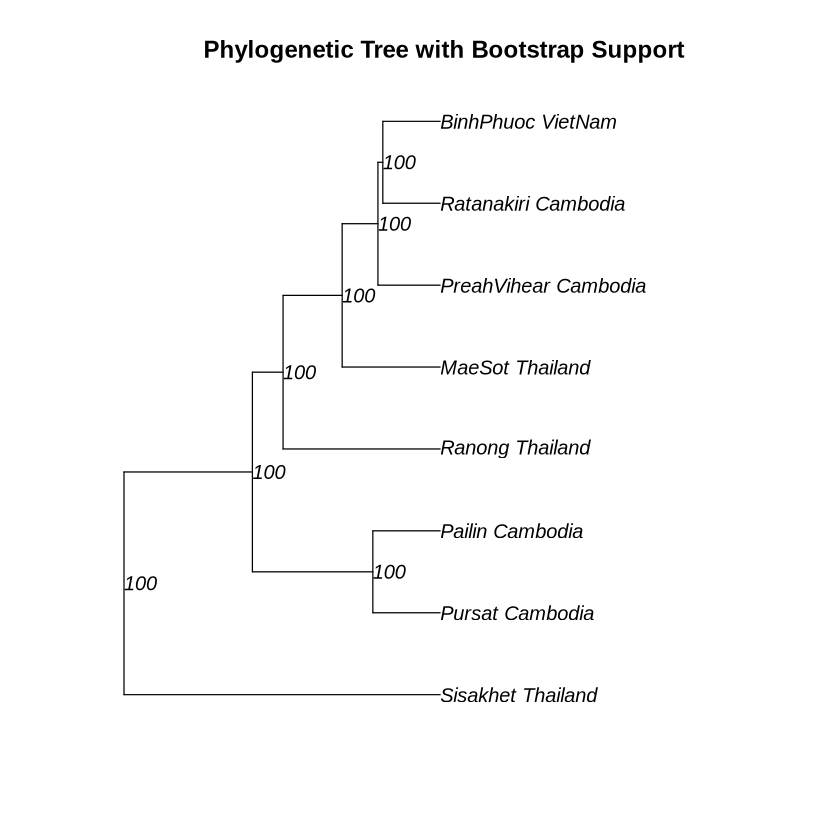

In [ ]:
par(bg="white")
plot(tree, 
     main = "Phylogenetic Tree with Bootstrap Support", 
     show.node.label = TRUE)    # Show bootstrap values on the node

In [ ]:
# Save the tree plot as a PNG file
png("tree_plot.png", width = 800, height = 600)
print(Sitecounttree_white)
dev.off()  # Close the device and save the plot


$edge
      [,1] [,2]
 [1,]    9    2
 [2,]    9   10
 [3,]   10   11
 [4,]   11    6
 [5,]   11    7
 [6,]   10   12
 [7,]   12    3
 [8,]   12   13
 [9,]   13    1
[10,]   13   14
[11,]   14    5
[12,]   14   15
[13,]   15    4
[14,]   15    8

$edge.length
 [1] 9.106183e-04 3.698367e-04 3.469164e-04 1.938652e-04 1.938652e-04
 [6] 8.834249e-05 4.524391e-04 1.702116e-04 2.822275e-04 1.030267e-04
[11] 1.792008e-04 1.408637e-05 1.651144e-04 1.651144e-04

$tip.label
[1] "MaeSot_Thailand"      "Sisakhet_Thailand"    "Ranong_Thailand"     
[4] "Ratanakiri_Cambodia"  "PreahVihear_Cambodia" "Pursat_Cambodia"     
[7] "Pailin_Cambodia"      "BinhPhuoc_VietNam"   

$Nnode
[1] 7

$node.label
[1] 100 100 100 100 100 100 100

attr(,"class")
[1] "phylo"
attr(,"order")
[1] "cladewise"


pdf 
  2

In [6]:
provesti_dist<-readRDS("/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/Structure/phylogenetics/white2011_dist_provesti.rds")


In [7]:
nj_Tree <- provesti_dist %>%
  nj() %>%    # calculate neighbor-joining tree
  ladderize() # organize branches by clade

#nj_Tree$edge.length


In [23]:
str(nj_Tree)

List of 4
 $ edge       : int [1:893, 1:2] 449 450 451 452 453 454 466 467 468 476 ...
 $ edge.length: num [1:893] 1.13e-06 1.56e-06 6.63e-06 1.44e-06 4.71e-06 ...
 $ tip.label  : chr [1:448] "PD0461-C" "PD0462-C" "PD0467-C" "PD0470-C" ...
 $ Nnode      : int 446
 - attr(*, "class")= chr "phylo"
 - attr(*, "order")= chr "cladewise"


In [8]:
# Get the number of edge lengths
length(nj_Tree$edge.length)

# Find indices of negative edge lengths
negative_edges <- which(nj_Tree$edge.length < 0)

# Print the negative edge lengths and their indices
if (length(negative_edges) > 0) {
  cat("Negative edge lengths found at indices:\n")
  print(negative_edges)
  cat("Values of negative edge lengths:\n")
  print(nj_Tree$edge.length[negative_edges])
  
  # Set all negative edge lengths to 0
  nj_Tree$edge.length[negative_edges] <- 0
  cat("Negative edge lengths have been set to 0.\n")
} else {
  cat("No negative edge lengths found.\n")
}


[1] 893

Negative edge lengths found at indices:
  [1]  38  40  41  42  44  47  48  50  51  52  55  70  72  73  74  75  76  79
 [19]  81  88  95  96  97  98 115 116 121 131 132 134 135 138 174 176 177 178
 [37] 180 202 208 217 231 258 259 260 262 263 264 265 267 268 269 271 280 301
 [55] 302 314 316 317 318 335 336 339 352 366 369 371 372 373 408 415 423 444
 [73] 445 446 467 469 488 530 532 533 534 535 536 549 550 584 586 587 588 589
 [91] 590 592 594 596 597 615 621 645 646 647 648 649 655 658 673 674 677 686
[109] 687 694 695 696 707 708 709 712 724 726 728 736 824 832 839 866 868
Values of negative edge lengths:
  [1] -1.006885e-06 -1.285123e-06 -8.226073e-07 -7.939086e-07 -9.253059e-07
  [6] -2.013647e-06 -8.524918e-06 -6.889884e-06 -3.163256e-05 -3.597714e-05
 [11] -2.200027e-06 -5.976627e-07 -1.367680e-06 -1.528883e-06 -1.188063e-06
 [16] -8.743164e-07 -5.888938e-07 -1.167626e-06 -1.030104e-05 -2.349174e-05
 [21] -2.121150e-06 -1.623780e-06 -8.858841e-07 -8.320098e-08 -2.282277e-06
 [26]

In [24]:
print(nj_Tree$edge.length[negative_edges])



  [1] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [38] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [75] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
[112] 0 0 0 0 0 0 0 0 0 0 0 0 0 0


In [33]:
str(md_white2011)

'data.frame':	448 obs. of  11 variables:
 $ Sample     : chr  "PD0461-C" "PD0462-C" "PD0467-C" "PD0470-C" ...
 $ Study      : chr  "1052-PF-TRAC-WHITE" "1052-PF-TRAC-WHITE" "1052-PF-TRAC-WHITE" "1052-PF-TRAC-WHITE" ...
 $ Site       : chr  "MaeSot" "MaeSot" "MaeSot" "MaeSot" ...
 $ Country    : chr  "Thailand" "Thailand" "Thailand" "Thailand" ...
 $ Year       : int  2011 2011 2011 2011 2011 2011 2011 2011 2011 2011 ...
 $ ENA        : chr  "ERR164731" "ERR164726" "ERR164725" "ERR164729" ...
 $ Population : chr  "WSEA" "WSEA" "WSEA" "WSEA" ...
 $ QC_pass    : chr  "True" "True" "True" "True" ...
 $ Fws        : num  0.999 0.999 0.999 0.998 0.999 ...
 $ Artemisinin: chr  "Sensitive" "Resistant" "Sensitive" "Resistant" ...
 $ SiteCountry: chr  "MaeSot_Thailand" "MaeSot_Thailand" "MaeSot_Thailand" "MaeSot_Thailand" ...


In [9]:
site_country_colors <- c(
  "MaeSot_Thailand" = "red",
  "Sisakhet_Thailand" = "brown",
  "Ranong_Thailand" = "orange",
  "Ratanakiri_Cambodia" = "chartreuse4",
  "PreahVihear_Cambodia" = "purple",
  "Pursat_Cambodia" = "blue2",
  "Pailin_Cambodia" = "skyblue",
  "BinhPhuoc_VietNam" = "darkolivegreen"
)

In [19]:

# Assume `Individual_ID` is the column in `md_white2011` corresponding to `nj_Tree$tip.label`
tree_data <- data.frame(Individual_ID = nj_Tree$tip.label)

# Join tree labels with metadata
tree_meta <- tree_data %>%
  left_join(md_white2011, by = c("Individual_ID"="Sample"))

tree_meta$SiteCountry <- factor(tree_meta$SiteCountry, levels = names(site_country_colors))

table(tree_meta$SiteCountry)


     MaeSot_Thailand    Sisakhet_Thailand      Ranong_Thailand 
                  75                   17                   18 
 Ratanakiri_Cambodia PreahVihear_Cambodia      Pursat_Cambodia 
                  56                   74                   67 
     Pailin_Cambodia    BinhPhuoc_VietNam 
                  70                   71 

In [20]:
tree_meta$Color <- site_country_colors[as.character(tree_meta$SiteCountry)]
table(tree_meta$Color)


         blue2          brown    chartreuse4 darkolivegreen         orange 
            67             17             56             71             18 
        purple            red        skyblue 
            74             75             70 

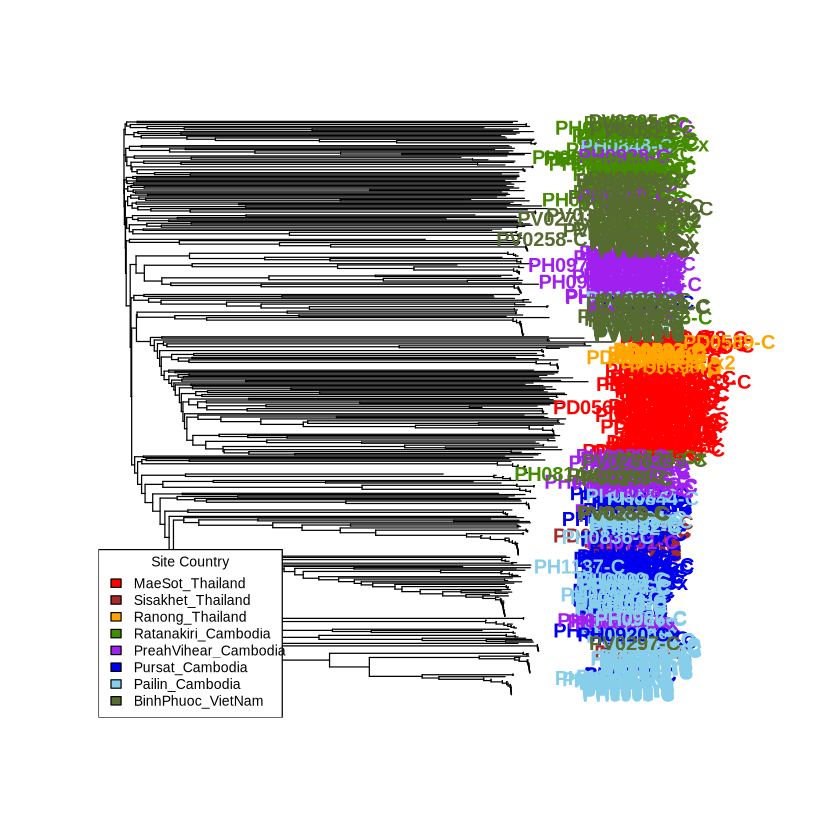

In [21]:

# Set the background and plot parameters
par(bg = "white")

# Plot the phylogenetic tree without tip labels
plot.phylo(
  nj_Tree, 
  cex = 1, 
  font = 2, 
  tip.color = tree_meta$Color, 
  label.offset = 0.0005, 
  type = "phylogram", 
  show.tip.label = T
)

# Add legend to the plot
legend(
  "bottomleft", 
  legend = names(site_country_colors), 
  fill = site_country_colors, 
  title = "Site Country", 
  cex = 0.7
)


In [ ]:
# Open a PNG device
#png("phylogenetic_tree_plot.png", width = 1000, height = 1200)  # Adjust resolution and size as needed
png("phyl_sc.png", width = 1700, height = 1800, res = 300)  # Higher resolution

# Adjust margin sizes: c(bottom, left, top, right)
par(bg = "white", mar = c(2, 2, 2, 2))  # Reducing margins for a more compact plot

# Plot the phylogenetic tree without tip labels
plot.phylo(
  nj_Tree, 
  cex = 1, 
  font = 2, 
  tip.color = tree_meta$Color, 
  label.offset = 0.0005, 
  type = "unrooted", 
  show.tip.label = FALSE
)

# Add circles as tip labels
tiplabels(
  pch = 21, 
  bg = tree_meta$Color, 
  cex = 1.2, 
  offset = 0.00001
)


# Adjust legend placement
legend(
  "bottom", 
  legend = names(site_country_colors), 
  fill = site_country_colors, 
  title = "Site Country", 
  cex = 0.7, 
  inset = 0.01
)

dev.off()


Warning message in tiplabels(pch = 21, bg = tree_meta$Color, cex = 1.2, offset = 1e-05):
“argument 'offset' ignored with unrooted trees”


pdf 
  2

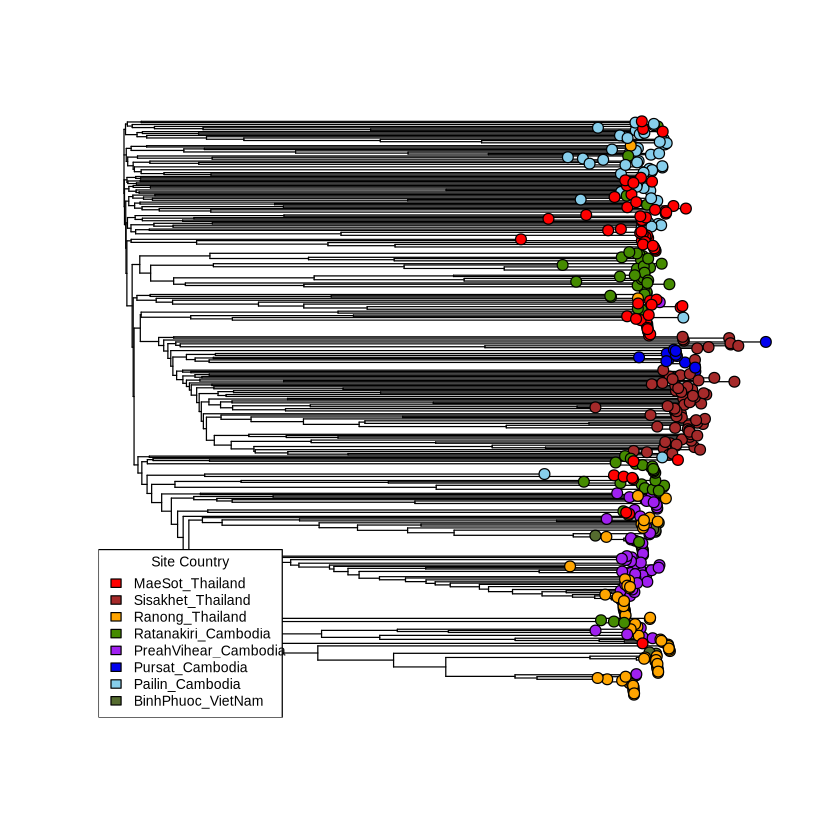

In [15]:

# Set the background and plot parameters
par(bg = "white")

# Plot the phylogenetic tree without tip labels
plot.phylo(
  nj_Tree, 
  cex = 1, 
  font = 2, 
  tip.color = cols, 
  label.offset = 0.0005, 
  type = "phylogram", 
  show.tip.label = FALSE
)

# Add circles as tip labels
tiplabels(
  pch = 21, 
  bg = cols, 
  cex = 1.2, 
  offset = 0.00001  # Adjust size or position of circles as needed
)


# Add legend to the plot
legend(
  "bottomleft", 
  legend = names(site_country_colors), 
  fill = site_country_colors, 
  title = "Site Country", 
  cex = 0.7
)

In [47]:
par(bg = "white")  # Set the background color to white
png("phyl_c_l.png", width = 1700, height = 1800, res = 300)  # Higher resolution

# Define a set of colors for the clusters
cols <- c("red", "brown", "orange", "chartreuse4", "purple",
          "blue2", "skyblue", "cyan")

# Load the cluster data
clus_white <- readRDS("/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/Structure/Dapc/White_ABfilt_DAPC/clus_white2011.rds")

# Plot the neighbor-joining tree
plot.phylo(
  nj_Tree, 
  cex = 0.8,         # Font size for labels
  font = 2,          # Font style
  adj = 0,           # Label adjustment
  # tip.color = cols[clus_white$grp],  # Uncomment if you want to color labels by cluster
  #label.offset = 0.0005,  # Distance of labels from the tips
  type = "unrooted",     # Type of phylogenetic tree
  show.tip.label = FALSE  # Do not show tip labels directly
)

# Add colored circles as tip labels to represent clusters
tiplabels(
  pch = 21,                    # Circle shape
  bg = cols[clus_white$grp],   # Background color based on cluster
  cex = 1.2,                   # Circle size
  offset = 0.00001             # Adjust circle position
)

# Dynamically create the legend using unique cluster groups
legend(
  "bottomleft", 
  legend = paste("Cluster", unique(clus_white$grp)),  # Unique cluster labels
  fill = cols[unique(clus_white$grp)],               # Corresponding colors
  title = "Site Country", 
  cex = 0.7  # Legend text size
)

# Add a phylogenetic axis to the plot
#axisPhylo(3)  # Add an axis to the top of the plot

dev.off()

Warning message in tiplabels(pch = 21, bg = cols[clus_white$grp], cex = 1.2, offset = 1e-05):
“argument 'offset' ignored with unrooted trees”


pdf 
  2

Warning message in tiplabels(pch = 21, bg = cluster_colors[as.character(clus_white$grp)], :
“argument 'offset' ignored with unrooted trees”


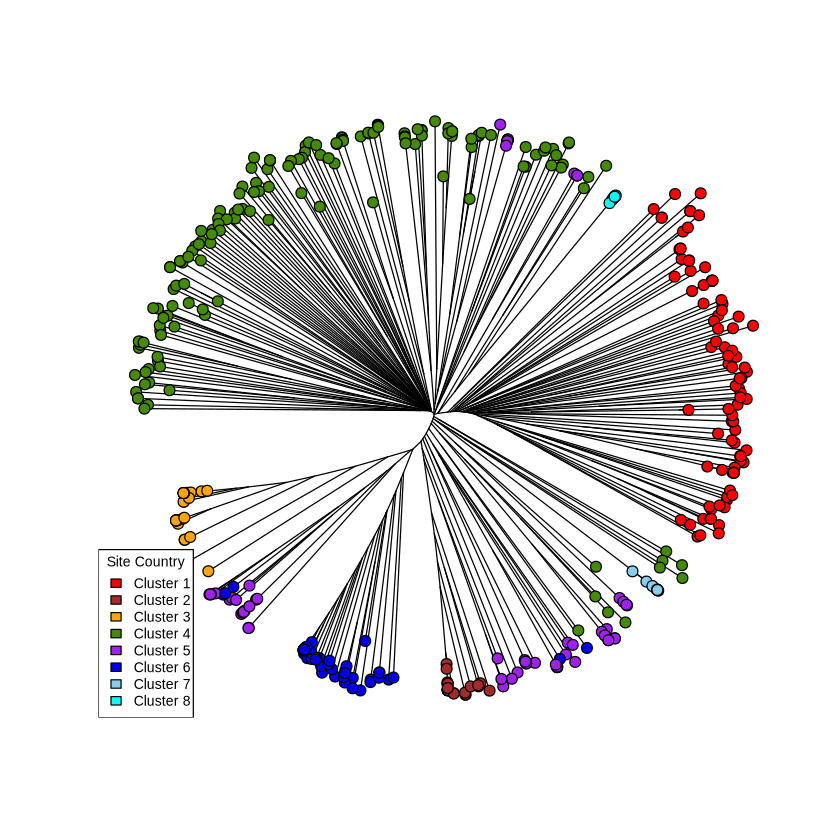

In [62]:
par(bg = "white")  # Set the background color to white

# Define a named vector for cluster colors
cluster_colors <- c(
  "1" = "red",          # Cluster 1: Red
  "2" = "brown",        # Cluster 2: Brown
  "3" = "orange",       # Cluster 3: Orange
  "4" = "chartreuse4",  # Cluster 4: Chartreuse4
  "5" = "purple",       # Cluster 5: Purple
  "6" = "blue2",        # Cluster 6: Blue2
  "7" = "skyblue",      # Cluster 7: Skyblue
  "8" = "cyan"          # Cluster 8: Cyan
)

# Load the cluster data
clus_white <- readRDS("/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/Structure/Dapc/White_ABfilt_DAPC/clus_white2011.rds")

# Plot the neighbor-joining tree
plot.phylo(
  nj_Tree, 
  cex = 0.8,         # Font size for labels
  font = 2,          # Font style
  adj = 0,           # Label adjustment
  label.offset = 0.0005,  # Distance of labels from the tips
  type = "unrooted",     # Type of phylogenetic tree
  show.tip.label = FALSE  # Do not show tip labels directly
)

# Add colored circles as tip labels to represent clusters
tiplabels(
  pch = 21,                               # Circle shape
  bg = cluster_colors[as.character(clus_white$grp)],  # Map cluster groups to colors
  cex = 1.2,                              # Circle size
  offset = 0.00001                        # Adjust circle position
)

# Create a legend for the clusters
legend(
  "bottomleft", 
  legend = paste("Cluster", names(cluster_colors)),  # Cluster names
  fill = cluster_colors,                            # Corresponding colors
  title = "Site Country", 
  cex = 0.7  # Legend text size
)



Top 30 maesot inds

These individuals are not found in the tree tip labels:
[1] "Individual"


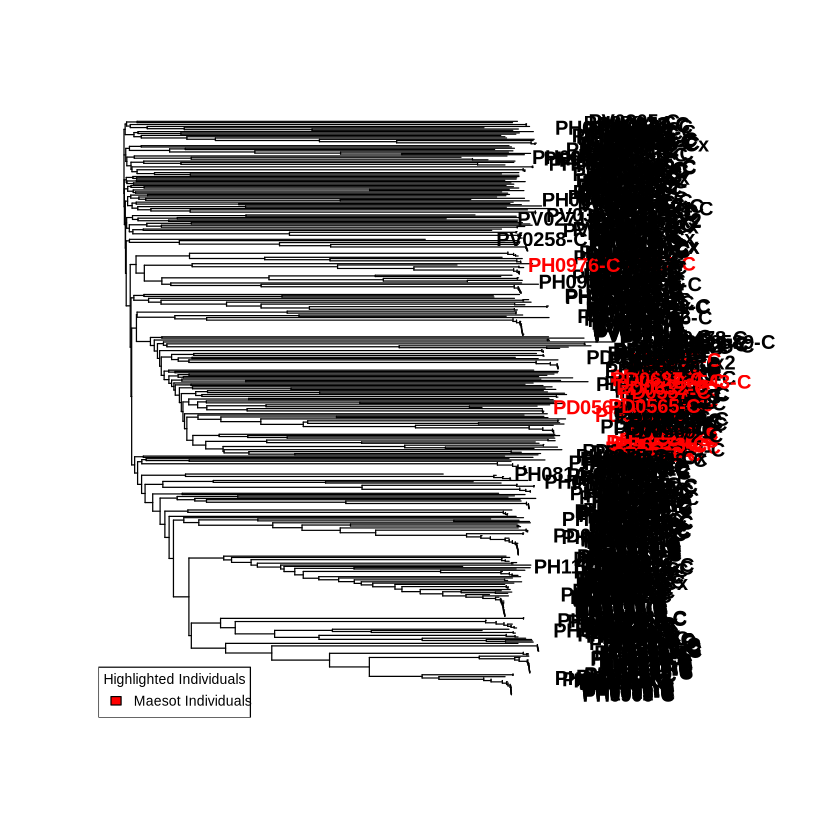

In [ ]:
# List of individuals to highlight
highlight_individuals <- c(
 "PD0497-C", "PD0473-C", "PD0477-C", "PD0496-C", "PD0470-C", 
  "PD0571-C", "PD0550-C", "PD0565-C", "PD0562-C", "PD0557-C", "PD0559-C", 
  "PD0629-C", "PD0514-C", "PD0535-C", "PD0637-C", "PD0495-C", "PD0476-C", 
  "PD0529-C", "PD0543-C", "PH0976-C", "PD0472-C", "PD0544-C", "PD0532-C", 
  "PD0547-C", "PD0567-C", "PD0553-C", "PD0632-C", "PH0524-C", "PD0520-C", 
  "PD0573-C",
)

# Check if all the individuals are part of the tree tip labels
missing_labels <- setdiff(highlight_individuals, nj_Tree$tip.label)
if (length(missing_labels) > 0) {
  cat("These individuals are not found in the tree tip labels:\n")
  print(missing_labels)
} else {
  cat("All individuals are found in the tree tip labels.\n")
}

# Set background and plot parameters
par(bg = "white")

# Create a color vector: by default, the color for highlighted tips is "red"
tip_colors <- rep("black", length(nj_Tree$tip.label))  # Set default color for all tips
highlight_indices <- which(nj_Tree$tip.label %in% highlight_individuals)  # Find indices of individuals to highlight
tip_colors[highlight_indices] <- "red"  # Change color to red for highlighted individuals

# Plot the phylogenetic tree without tip labels
plot.phylo(
  nj_Tree, 
  cex = 1, 
  font = 2, 
  label.offset = 0.0005, 
  type = "phylogram", 
  show.tip.label = TRUE, 
  tip.color = tip_colors  # Apply color to the tips
)

# Add legend to the plot (if needed)
legend(
  "bottomleft", 
  legend = c("Maesot Individuals"), 
  fill = "red", 
  title = "Highlighted Individuals", 
  cex = 0.7
)


In [29]:
# Custom metadata to store highlighted individuals
highlight_metadata <- paste("Highlighted individuals: ", paste(highlight_individuals, collapse = ", "))

# Write the tree in Nexus format without comments first
nexus_file <- "Maesot_tree_with_metadata.nex"
write.nexus(nj_Tree, file = nexus_file)

# Open the file and append custom metadata as a comment
file_conn <- file(nexus_file, open = "a")  # Open file for appending
writeLines(paste("#", highlight_metadata), file_conn)  # Add metadata as a comment
close(file_conn)

cat("Tree with highlight metadata saved as Nexus file:", nexus_file)



Tree with highlight metadata saved as Nexus file: Maesot_tree_with_metadata.nex

In [ ]:
ape::write.nexus(nj_Tree, file="/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/Structure/phylogenetics/White_tree_provesti.nexus")
